# Tutorial 1

In this tutorial, we will learn how to classify with logistic regression.

## Imports

In [1]:
import torch
from torch import Tensor
import numpy as np

import matplotlib.pyplot as plt
from  matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png', 'pdf')

## Exercise 1

Suppose you have five input points, $\textbf{x}_1=(2,-1)$, $\textbf{x}_2=(0,1)$,
$\textbf{x}_3=(2,1)$, $\textbf{x}_4=(0,-2)$, $\textbf{x}_5=(-2,-2)$, $\textbf{x}_6=(-1,0)$ and the corresponding classes are $y_1=y_2=y_3=y_6=0$ and $y_4=y_5=1$:

In [2]:
x = torch.tensor([
    [2, -1],
    [0, 1],
    [2, 1],
    [0, -2],
    [-2, -2],
    [-1, 0]
])
y_gt = torch.tensor([0, 0, 0, 1, 1, 0])
labs = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

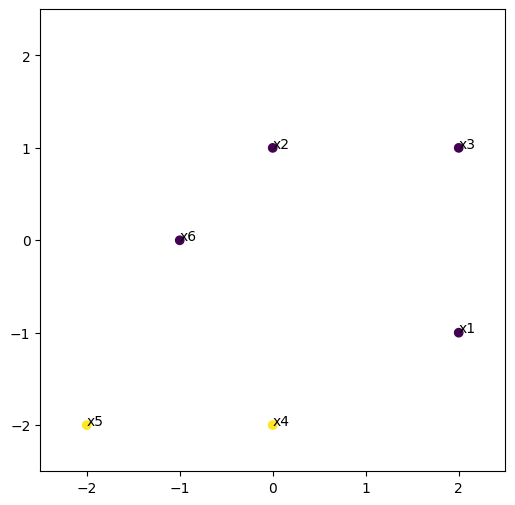

In [3]:
fig, ax = plt.subplots(1,1, figsize=(6, 6))
plt.scatter(x[:, 0], x[:, 1], c=y_gt)
for i, lab in enumerate(labs):
    plt.annotate(lab, (x[i, 0], x[i, 1]))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
plt.show()

Consider a logistic regression model
$\hat{y}_i=\sigma\left(\alpha_0+\alpha_1x_{i1}+\alpha_2x_{i2}\right)$, with
$\sigma(\cdot)$ the sigmoid function, $\sigma(x)=\left(1+e^{-x}\right)^{-1}$.

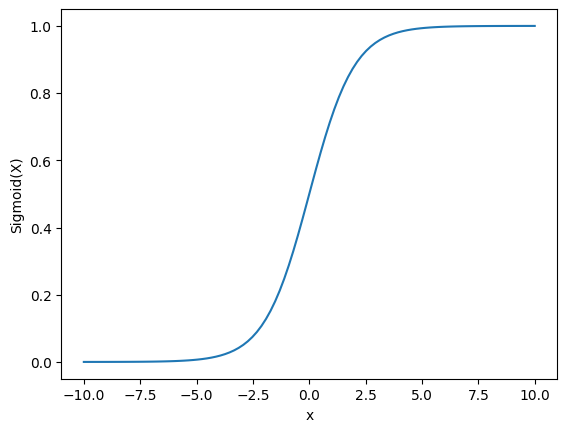

In [4]:
# Define a custom sigmoid function
def sigmoid(x: Tensor) -> Tensor:
    return 1 / (1 + torch.exp(-x))

x_plot = torch.linspace(-10, 10, 100) 
y_plot = sigmoid(x_plot) 
  
plt.plot(x_plot, y_plot) 
plt.xlabel("x") 
plt.ylabel("Sigmoid(X)") 
  
plt.show()

Assume a positive label is predicted when the output of the sigmoid is larger or equal than 0.5. Then what values for $\alpha_0$, $\alpha_1$ and $\alpha_2$ would result in the correct classification for this dataset?

**Hint**: A logistic regression classifier is nothing more than a hyper-plane
separating points of the two classes. If necessary, review vectors, dot-products and
their geometrical interpretation in linear algebra.

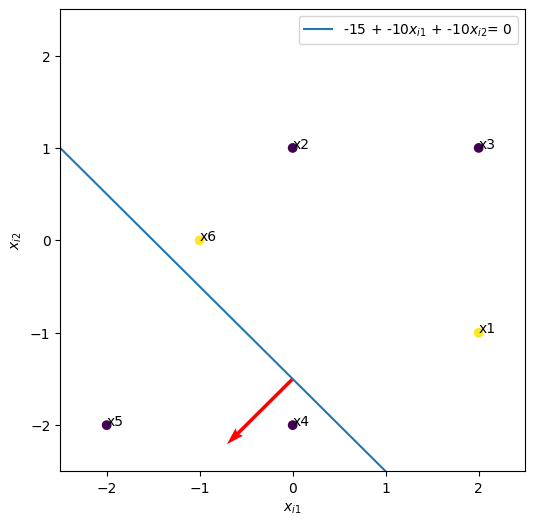

In [20]:
# Define a = [a0, a1, a2]
a0, a1, a2 = -15, -10, -10
a = torch.tensor([a0, a1, a2], dtype=torch.float)

# Extend the bias dimension x = [1, x[0], x[1]]
x_extend = torch.cat([torch.ones(x.shape[0], 1), x], dim=1)

# Calculate predictions y_pred
y_pred = sigmoid(x_extend @ a)

# Explanation
fig, ax = plt.subplots(1,1, figsize=(6, 6))
# Compute the decision boundary
if a2 != 0:
    x_line = np.linspace(-2.5, 2.5, 100)
    y_line = -(a0 + a1 * x_line) / a2
    ax.plot(x_line, y_line, label=f'{a0} + {a1}'+'$x_{i1}$' + f' + {a2}' + '$x_{i2}$' + '= 0')
elif a1 != 0:
    ax.axvline(-a0 / a1, label=f'{a0} + {a1}'+'$x_{i1}$' + f' + {a2}' + '$x_{i2}$' + '= 0')


if a2 != 0:
    x_center = 0
    y_center = -(a0 + a1 * x_center) / a2
elif a1 != 0:
    x_center = -a0 / a1
    y_center = 0

# Compute the normal vector
normal_vector = np.array([a1, a2])
normal_vector_length = np.linalg.norm(normal_vector)
normal_vector_unit = normal_vector / normal_vector_length
ax.quiver(x_center, y_center, normal_vector_unit[0], normal_vector_unit[1], angles='xy', scale_units='xy', scale=1, color='r')

ax.legend(loc='upper right')
plt.scatter(x[:, 0], x[:, 1], c=y_gt)
for i, lab in enumerate(labs):
    plt.annotate(lab, (x[i, 0], x[i, 1]))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
plt.xlabel('$x_{i1}$')
plt.ylabel('$x_{i2}$')
plt.show()

Let's investigate the obtained scores!

In [10]:
def print_scores(target: Tensor, scores: Tensor) -> None:
    [print('{}\t{}\t{:.2e}'.format('x' + str(i), int(t), float(s)))
     for i, (t, s) in enumerate(zip(target, scores), start=1)]

print_scores(y_gt, y_pred)

x1	0	1.39e-11
x2	0	1.39e-11
x3	0	2.86e-20
x4	1	9.93e-01
x5	1	1.00e+00
x6	0	6.69e-03


**Note:** There are many valid parametrization that lead to a separating hyperplane. How would you prioritize between them?

## Exercise 2

Continuing from the previous exercise, suppose the same input points with label $y_1=y_4=y_5=y_6=0$ and $y_2=y_3=1$:

In [11]:
y_gt = torch.tensor([0, 1, 1, 0, 0, 0])

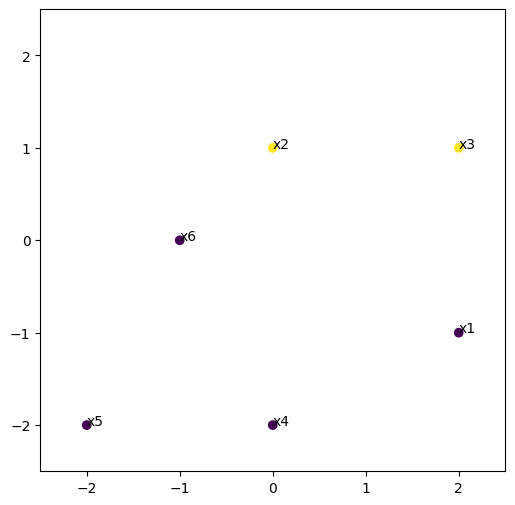

In [12]:
fig, ax = plt.subplots(1,1, figsize=(6, 6))
plt.scatter(x[:, 0], x[:, 1], c=y_gt)
for i, lab in enumerate(labs):
    plt.annotate(lab, (x[i, 0], x[i, 1]))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
plt.show()

Consider the same logistic regression model above with coefficients $\beta_0$, $\beta_1$
and $\beta_2$, how would you need to set these coefficients to correctly classify this
dataset?

x1	0	6.69e-03
x2	1	1.00e+00
x3	1	1.00e+00
x4	0	2.86e-20
x5	0	5.90e-29
x6	0	3.06e-07


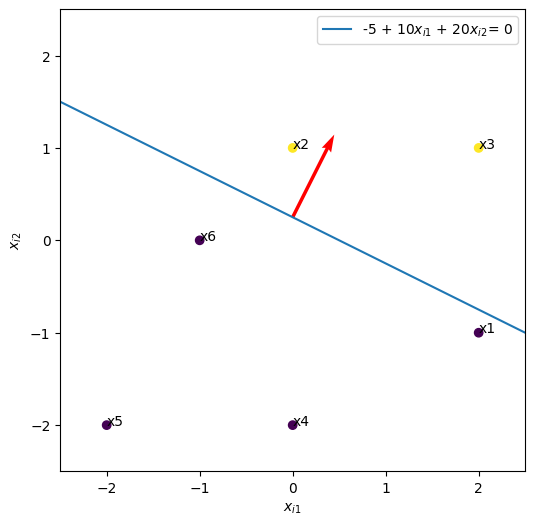

In [13]:
# Define the classifier with coefficients b0, b1, b2 and predict y_pred
b0, b1, b2 = -5, 10, 20
b = torch.tensor([b0, b1, b2], dtype=torch.float)
y_pred = sigmoid(x_extend @ b)
print_scores(y_gt, y_pred)

# Explanation
fig, ax = plt.subplots(1,1, figsize=(6, 6))
# Compute the decision boundary
if b2 != 0:
    x_line = np.linspace(-2.5, 2.5, 100)
    y_line = -(b0 + b1 * x_line) / b2
    ax.plot(x_line, y_line, label=f'{b0} + {b1}'+'$x_{i1}$' + f' + {b2}' + '$x_{i2}$' + '= 0')
elif b1 != 0:
    ax.axvline(-b0 / b1, label=f'{b0} + {b1}'+'$x_{i1}$' + f' + {b2}' + '$x_{i2}$' + '= 0')


if b2 != 0:
    x_center = 0
    y_center = -(b0 + b1 * x_center) / b2
elif b1 != 0:
    x_center = -b0 / b1
    y_center = 0

# Compute the normal vector
normal_vector = np.array([b1, b2])
normal_vector_length = np.linalg.norm(normal_vector)
normal_vector_unit = normal_vector / normal_vector_length
ax.quiver(x_center, y_center, normal_vector_unit[0], normal_vector_unit[1], angles='xy', scale_units='xy', scale=1, color='r')

ax.legend(loc='upper right')
plt.scatter(x[:, 0], x[:, 1], c=y_gt)
for i, lab in enumerate(labs):
    plt.annotate(lab, (x[i, 0], x[i, 1]))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
plt.xlabel('$x_{i1}$')
plt.ylabel('$x_{i2}$')
plt.show()

Make sure that the second and third elements are close to one, and the others close to zero.

## Exercise 3

Continuing from the previous exercise, suppose the same input points with label $y_2=y_3=y_4=y_5=0$ and $y_1=y_6=1$:

In [14]:
y_gt = torch.tensor([1, 0, 0, 0, 0, 1])

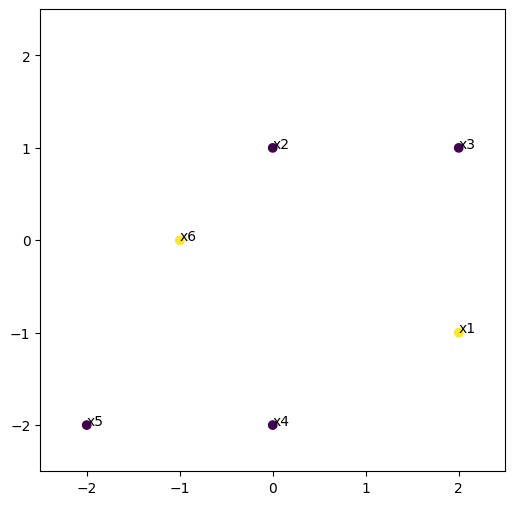

In [15]:
fig, ax = plt.subplots(1,1, figsize=(6, 6))
plt.scatter(x[:, 0], x[:, 1], c=y_gt)
for i, lab in enumerate(labs):
    plt.annotate(lab, (x[i, 0], x[i, 1]))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
plt.show()

Clearly, logistic regression cannot correctly classify this dataset, since the two classes are not linearly separable (Optional: you can try to prove it after class).

However, as we have shown in the previous exercises, it is possible to separate $x_2$ and $x_3$ from the rest, and $x_4$ and $x_5$ from the rest. Can these two simple classifiers be composed into one that is powerful enough to separate $x_1$ from the rest?

Let $z_{i1}=\sigma(\alpha_0+\alpha_1x_{i1}+\alpha_2x_{i2})$ and $z_{i2}=\sigma(\beta_0+\beta_1x_{i1}+\beta_2x_{i2})$ be the output of the two logistic regression classifiers for point $i$. Then, the dataset would become:

| $i$ | $z_{i1}$ | $z_{i2}$ | $y$ |
|:-----|:----------|:----------|:-----|
| $1$ |        0 |        0 |   1 |
| $2$ |        0 |        1 |   0 |
| $3$ |        0 |        1 |   0 |
| $4$ |        1 |        0 |   0 |
| $5$ |        1 |        0 |   0 |
| $6$ |        0 |        0 |   1 |

In graphical form:

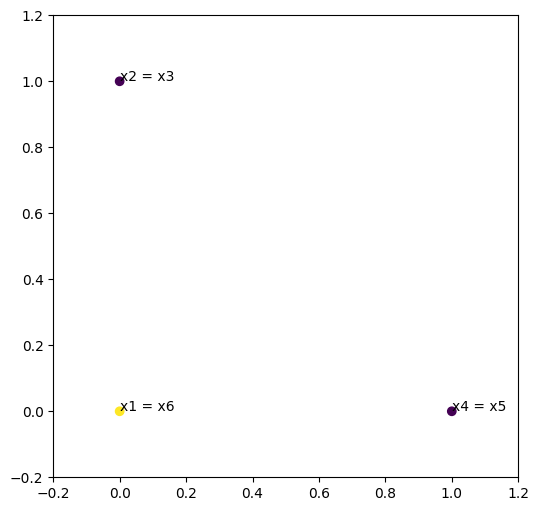

In [16]:
fig, ax = plt.subplots(1,1, figsize=(6, 6))
x_axis = [0, 0, 1]
y_axis = [0, 1, 0]
plt.scatter(x_axis, y_axis, c=[1, 0, 0])
for i, lab in enumerate(['x1 = x6', 'x2 = x3', 'x4 = x5']):
    plt.annotate(lab, (x_axis[i], y_axis[i]))
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
plt.show()

This sure looks linearly separable! As before, if we find the coefficients for a linear
classifier $\hat{y}_i=\sigma\left(\gamma_0+\gamma_1z_{i1}+\gamma_2z_{i2}\right)$, we can classify the input points as required. 

Please finish the entire big classifier based on variables x, a, b from previous blocks.

In [17]:
# Compute z1 with x and a
z1 = sigmoid(x_extend @ a)

# Compute z2 with x and b
z2 = sigmoid(x_extend @ b)

# Define the classifier with coefficients g0, g1, g2
g0, g1, g2 = 5, -10, -10
g = torch.tensor([g0, g1, g2], dtype=torch.float)

# Compute y with z1, z2 and g
z_extend = torch.stack([torch.ones(z1.shape[0]), z1, z2], dim=1)
print_scores(y_gt, sigmoid(z_extend @ g))

x1	1	9.93e-01
x2	0	6.69e-03
x3	0	6.69e-03
x4	0	7.15e-03
x5	0	6.69e-03
x6	1	9.93e-01


And this is just what a neural network looks like!
Each neuron is a simple linear classifier, and we just stack linear classifiers on
top of linear classifiers. And we could go on and on, with many layers of linear
classifiers.